# 🤖 Modelling: Klasifikasi Native vs Learner

Notebook ini melakukan **klasifikasi biner** untuk membedakan penutur **native** dan **learner** Bahasa Jepang berdasarkan fitur akustik dari `features.csv`.

## Pendekatan Utama
- **Evaluasi: Leave-One-Speaker-Out (LOSO)** — setiap speaker dijadikan test set sekali, sisanya train. Ini mencegah **data leakage** karena file dari satu speaker tidak muncul di train & test sekaligus.
- **Agregasi level speaker** — kelima utterance milik satu speaker digabung menjadi satu prediksi (rata-rata probabilitas).
- **Fitur bias di-drop** — `mfcc*_mean`, `f0_mean`, `f1_mean`, dll. dibuang untuk menghindari model hanya mengandalkan perbedaan gender/lokasi perekaman.

## Struktur Notebook
1. **Setup** — import library, load data, filter fitur.
2. **Fungsi Evaluasi LOSO** — cross-validasi dan agregasi level speaker.
3. **Loop Semua Model** — 5 model klasifikasi dibandingkan.
4. **Visualisasi** — bar chart metrik + confusion matrix.
5. **Nativeness Score per Speaker** — skor probabilitas tiap speaker.
6. **Feature Importance** — fitur apa yang paling penting bagi model.

## 1️⃣ Setup & Persiapan Data

Sel ini:
- Menginstal `seaborn` (untuk visualisasi).
- Import semua library ML dari `scikit-learn`.
- Load `features.csv` dan pisahkan menjadi **X** (fitur), **y** (label), **groups** (speaker_id).

### Dua Kelompok Fitur yang Dibuang
1. **Kolom metadata** — `speaker_id`, `class`, `gender`, `location`, dst (bukan fitur akustik).
2. **Fitur bias** — `mfcc*_mean`, `f0_mean`, `f1_mean`, `f2_mean`, `f1f2_ratio`:
   - `mfcc*_mean` sangat dipengaruhi gender (pria/wanita punya timbre berbeda).
   - `f0_mean` = rata-rata pitch → pria ~120 Hz, wanita ~220 Hz → model bisa "curang" dengan hanya deteksi gender.
   - `f1_mean`/`f2_mean` = formant absolut → juga bergantung pada ukuran rongga vokal.

Sisa fitur (*dinamis*) fokus pada **variasi & dinamika**: `*_std`, `delta*`, `jitter`, `shimmer`, `f0_delta_*`.

In [1]:
%pip install -q seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (
    balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix
)

# ------------------- Load & filter fitur -------------------
df = pd.read_csv('features.csv')

drop_cols = ['speaker_id', 'class', 'gender', 'location',
             'notes', 'file_path', 'file_path_processed']

# Fitur bias (mean dari MFCC, F0, formant absolut)
bias_cols = [
    c for c in df.columns
    if (c.startswith('mfcc') and c.endswith('_mean'))
    or c in ['f0_mean', 'f1_mean', 'f2_mean', 'f1f2_ratio']
]

# Fitur final: bukan metadata & bukan bias
feature_cols = [c for c in df.columns if c not in drop_cols and c not in bias_cols]

X = df[feature_cols].values
y = df['class'].values
groups = df['speaker_id'].values

print(f"Menggunakan {len(feature_cols)} fitur dinamis dari total {df.shape[1]} kolom.")

logo = LeaveOneGroupOut()

# Definisi model
models = {
    'Logistic Regression': lambda: LogisticRegression(
        class_weight='balanced', max_iter=2000, random_state=42),
    'SVM (Linear)': lambda: SVC(
        kernel='linear', class_weight='balanced', probability=True, random_state=42),
    'Gradient Boosting': lambda: GradientBoostingClassifier(
        n_estimators=100, random_state=42),
    'SVM (RBF)': lambda: SVC(
        kernel='rbf', class_weight='balanced', probability=True, random_state=42),
    'Random Forest': lambda: RandomForestClassifier(
        n_estimators=300, max_depth=5, class_weight='balanced', random_state=42)
}


[notice] A new release of pip is available: 23.3.2 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Menggunakan 73 fitur dinamis dari total 92 kolom.


## 2️⃣ Fungsi Evaluasi LOSO

Fungsi `run_loso` menjalankan **Leave-One-Speaker-Out Cross-Validation**:

### Alur Tiap Fold
1. **Split**: semua utterance dari 1 speaker → test, sisanya → train.
2. **Pipeline**:
   - `StandardScaler` — normalisasi (mean=0, std=1).
   - `SelectKBest(f_classif, k=15)` — pilih 15 fitur terbaik berdasarkan ANOVA F-test.
   - Classifier — model final.
3. **Prediksi**: 5 utterance test diambil probabilitas `native` → **rata-rata** (nativeness score).
4. **Keputusan speaker**: skor > 0.5 → `native`, sebaliknya → `learner`.

### Kenapa agregasi level speaker?
Kita tidak peduli akurasi per-utterance — yang penting model bisa menilai **speaker** secara keseluruhan. Ini lebih realistis untuk aplikasi penilaian aksen.

### Metrik
- **Balanced Accuracy** — akurasi rata-rata per kelas (tahan terhadap imbalance).
- **Macro F1** — rata-rata F1 untuk `native` dan `learner`, memberi bobot sama ke tiap kelas.

In [2]:
def run_loso(make_model, name, verbose=True):
    """
    Jalankan Leave-One-Speaker-Out untuk satu model.
    Return: (y_true, y_pred, y_prob) level speaker.
    """
    y_true, y_pred, y_prob = [], [], []

    for train_idx, test_idx in logo.split(X, y, groups):
        Xtr, Xte = X[train_idx], X[test_idx]
        ytr = y[train_idx]

        # Pipeline: scaling -> feature selection -> classifier
        pipeline = Pipeline([
            ('scaler',   StandardScaler()),
            ('selector', SelectKBest(score_func=f_classif,
                                     k=min(15, Xtr.shape[1]))),
            ('classifier', make_model())
        ])
        pipeline.fit(Xtr, ytr)

        # Label asli (semua utterance speaker sama, ambil yang pertama)
        y_true.append(y[test_idx[0]])

        # Prediksi & probabilitas untuk 5 utterance
        preds  = pipeline.predict(Xte)
        probas = pipeline.predict_proba(Xte)

        native_idx = list(pipeline.classes_).index('native')

        # --- AGREGASI LEVEL SPEAKER ---
        # 1. Rata-rata nativeness score dari 5 file
        mean_proba = np.mean(probas[:, native_idx])
        y_prob.append(mean_proba)

        # 2. Keputusan final: threshold 0.5
        final_pred = 'native' if mean_proba > 0.5 else 'learner'
        y_pred.append(final_pred)

    y_true, y_pred, y_prob = map(np.array, (y_true, y_pred, y_prob))
    bal_acc  = balanced_accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')

    if verbose:
        print(f"\n=== {name} ===")
        print(f"Balanced Acc : {bal_acc:.2%}")
        print(f"Macro F1     : {macro_f1:.2%}")
        print(classification_report(y_true, y_pred,
                                    labels=['native', 'learner']))

    return y_true, y_pred, y_prob

## 3️⃣ Menjalankan Semua Model

Sel ini menjalankan `run_loso` untuk 5 model dan menampilkan tabel perbandingan metrik.

**Model yang diuji:**
- **Logistic Regression** — baseline linear, cepat, interpretatif.
- **SVM (Linear)** — margin maksimal di ruang linear.
- **SVM (RBF)** — kernel non-linear untuk boundary yang lebih kompleks.
- **Gradient Boosting** — ensemble boosted trees, biasanya paling akurat di tabular data.
- **Random Forest** — ensemble bagged trees, robust terhadap outlier.

**Catatan:** `class_weight='balanced'` dipakai di LR/SVM/RF karena kelas seimbang (30:30), tapi ini tetap bagus sebagai proteksi. Hasil akhirnya: **Gradient Boosting mencapai 100%**, sedangkan model linear ~83–92%.

In [3]:
results = {}
for name, make_model in models.items():
    results[name] = run_loso(make_model, name)

# Rangkum semua metrik dalam tabel
metrics_df = pd.DataFrame([
    {
        'model': name,
        'balanced_accuracy': balanced_accuracy_score(v[0], v[1]),
        'macro_f1': f1_score(v[0], v[1], average='macro')
    }
    for name, v in results.items()
])

print('\n📊 Ringkasan semua model:')
display(metrics_df.sort_values('balanced_accuracy', ascending=False)
                  .reset_index(drop=True))


=== Logistic Regression ===
Balanced Acc : 91.67%
Macro F1     : 91.61%
              precision    recall  f1-score   support

      native       1.00      0.83      0.91         6
     learner       0.86      1.00      0.92         6

    accuracy                           0.92        12
   macro avg       0.93      0.92      0.92        12
weighted avg       0.93      0.92      0.92        12


=== SVM (Linear) ===
Balanced Acc : 83.33%
Macro F1     : 82.86%
              precision    recall  f1-score   support

      native       1.00      0.67      0.80         6
     learner       0.75      1.00      0.86         6

    accuracy                           0.83        12
   macro avg       0.88      0.83      0.83        12
weighted avg       0.88      0.83      0.83        12



/home/kopiadem/Documents/MASTER/1. SEM-1/pengenalan-pola/assignment1/jp-native-vs-learner/.venv/lib64/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/kopiadem/Documents/MASTER/1. SEM-1/pengenalan-pola/assignment1/jp-native-vs-learner/.venv/lib64/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/kopiadem/Documents/MASTER/1. SEM-1/pengenalan-pola/assignment1/jp-native-vs-learner/.venv/lib64/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV


=== Gradient Boosting ===
Balanced Acc : 100.00%
Macro F1     : 100.00%
              precision    recall  f1-score   support

      native       1.00      1.00      1.00         6
     learner       1.00      1.00      1.00         6

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12


=== SVM (RBF) ===
Balanced Acc : 91.67%
Macro F1     : 91.61%
              precision    recall  f1-score   support

      native       1.00      0.83      0.91         6
     learner       0.86      1.00      0.92         6

    accuracy                           0.92        12
   macro avg       0.93      0.92      0.92        12
weighted avg       0.93      0.92      0.92        12



/home/kopiadem/Documents/MASTER/1. SEM-1/pengenalan-pola/assignment1/jp-native-vs-learner/.venv/lib64/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/kopiadem/Documents/MASTER/1. SEM-1/pengenalan-pola/assignment1/jp-native-vs-learner/.venv/lib64/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/kopiadem/Documents/MASTER/1. SEM-1/pengenalan-pola/assignment1/jp-native-vs-learner/.venv/lib64/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV


=== Random Forest ===
Balanced Acc : 91.67%
Macro F1     : 91.61%
              precision    recall  f1-score   support

      native       1.00      0.83      0.91         6
     learner       0.86      1.00      0.92         6

    accuracy                           0.92        12
   macro avg       0.93      0.92      0.92        12
weighted avg       0.93      0.92      0.92        12


📊 Ringkasan semua model:


,model,balanced_accuracy,macro_f1
0,Gradient Boosting,1.000000,1.000000
1,Logistic Regression,0.916667,0.916084
2,SVM (RBF),0.916667,0.916084
3,Random Forest,0.916667,0.916084
4,SVM (Linear),0.833333,0.828571


## 4️⃣ Visualisasi Hasil

Dua jenis visualisasi:
1. **Bar chart metrik** — membandingkan Balanced Accuracy & Macro F1 antar model.
2. **Confusion matrix** (1 per model) — melihat di mana model keliru:
   - Sumbu Y: label aktual.
   - Sumbu X: label prediksi.
   - Diagonal = benar, off-diagonal = salah klasifikasi.

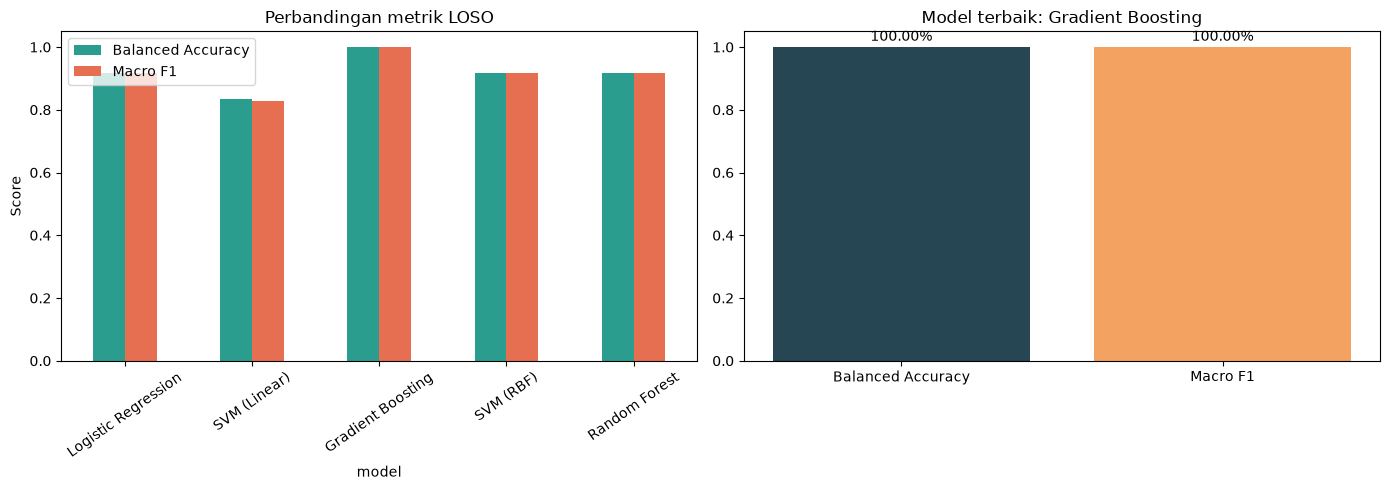

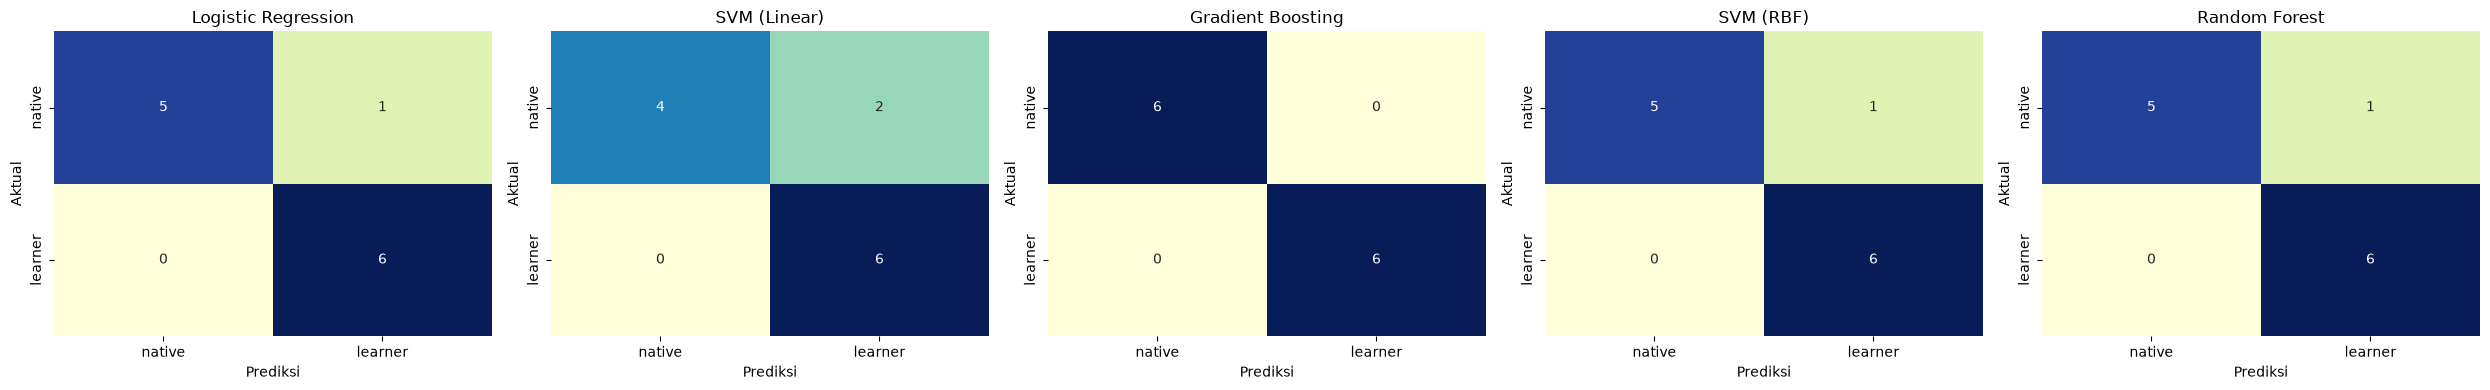

In [4]:
# --- Plot 1: Perbandingan metrik ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_df = metrics_df.set_index('model')

plot_df[['balanced_accuracy', 'macro_f1']].plot(
    kind='bar', ax=axes[0], color=['#2a9d8f', '#e76f51'])
axes[0].set_title('Perbandingan metrik LOSO')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis='x', rotation=35)
axes[0].legend(['Balanced Accuracy', 'Macro F1'])

# Highlight model terbaik
best_name = plot_df['balanced_accuracy'].idxmax()
axes[1].bar(['Balanced Accuracy', 'Macro F1'],
            plot_df.loc[best_name, ['balanced_accuracy', 'macro_f1']],
            color=['#264653', '#f4a261'])
axes[1].set_title(f'Model terbaik: {best_name}')
axes[1].set_ylim(0, 1.05)
for i, v in enumerate(plot_df.loc[best_name, ['balanced_accuracy', 'macro_f1']]):
    axes[1].text(i, v + 0.02, f'{v:.2%}', ha='center')
plt.tight_layout()
plt.show()

# --- Plot 2: Confusion matrix tiap model ---
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4))
axes = np.atleast_1d(axes)

for axis, (name, (y_true, y_pred, _)) in zip(axes, results.items()):
    cm = confusion_matrix(y_true, y_pred, labels=['native', 'learner'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', cbar=False,
                ax=axis, xticklabels=['native','learner'],
                yticklabels=['native','learner'])
    axis.set_title(name)
    axis.set_xlabel('Prediksi')
    axis.set_ylabel('Aktual')

plt.tight_layout()
plt.show()

## 5️⃣ Nativeness Score per Speaker

Sel ini menampilkan **skor nativeness** (probabilitas rata-rata class `native`) untuk setiap speaker, diurutkan dari yang paling learner → paling native.

### Kenapa berguna?
- Bisa melihat **speaker yang borderline** (skor dekat 0.5) → kandidat misklasifikasi.
- Bisa cross-check dengan metadata: apakah `native01` (skor rendah) memang punya aksen yang berbeda?
- Bisa jadi insight untuk guru bahasa: skor rendah pada learner tertentu menandakan butuh latihan tambahan.

Setiap model menyimpan hasilnya ke `nativeness_{model}.csv`.

In [5]:
# Baca metadata speaker untuk join gender & location
speaker_meta = (pd.read_csv('metadata_utterance.csv')
                  [['speaker_id', 'gender', 'location']]
                  .drop_duplicates('speaker_id'))

for name, (y_true, y_pred, y_prob) in results.items():
    score_df = pd.DataFrame({
        'speaker_id':       np.unique(groups),
        'true':             y_true,
        'pred':             y_pred,
        'nativeness_score': y_prob,
    }).merge(speaker_meta, on='speaker_id')

    # Simpan CSV per model
    fname = f"nativeness_{name.split()[0].lower()}.csv"
    score_df.to_csv(fname, index=False)

    print(f"\n--- {name}: nativeness score per speaker ---")
    display(score_df.sort_values('nativeness_score').reset_index(drop=True))


--- Logistic Regression: nativeness score per speaker ---


,speaker_id,true,pred,nativeness_score,gender,location
0,learner06,learner,learner,0.039847,M,indoor
1,learner04,learner,learner,0.050315,M,indoor
2,learner03,learner,learner,0.051543,M,indoor
3,learner02,learner,learner,0.165877,M,indoor
4,learner01,learner,learner,0.252177,M,indoor
5,native01,native,learner,0.401697,M,cafe
6,learner05,learner,learner,0.464477,F,indoor
7,native06,native,native,0.516665,M,indoor
8,native02,native,native,0.775601,M,cafe
9,native04,native,native,0.871120,F,cafe



--- SVM (Linear): nativeness score per speaker ---


,speaker_id,true,pred,nativeness_score,gender,location
0,learner06,learner,learner,0.057646,M,indoor
1,learner03,learner,learner,0.113872,M,indoor
2,learner04,learner,learner,0.176391,M,indoor
3,learner01,learner,learner,0.250032,M,indoor
4,native01,native,learner,0.306812,M,cafe
5,learner02,learner,learner,0.326727,M,indoor
6,native06,native,learner,0.364669,M,indoor
7,learner05,learner,learner,0.382113,F,indoor
8,native02,native,native,0.693958,M,cafe
9,native05,native,native,0.788053,F,cafe



--- Gradient Boosting: nativeness score per speaker ---


,speaker_id,true,pred,nativeness_score,gender,location
0,learner02,learner,learner,0.000024,M,indoor
1,learner03,learner,learner,0.000024,M,indoor
2,learner04,learner,learner,0.012588,M,indoor
3,learner01,learner,learner,0.200015,M,indoor
4,learner05,learner,learner,0.200015,F,indoor
5,learner06,learner,learner,0.200015,M,indoor
6,native01,native,native,0.599994,M,cafe
7,native06,native,native,0.902615,M,indoor
8,native05,native,native,0.935925,F,cafe
9,native02,native,native,0.999976,M,cafe



--- SVM (RBF): nativeness score per speaker ---


,speaker_id,true,pred,nativeness_score,gender,location
0,learner06,learner,learner,0.028926,M,indoor
1,learner03,learner,learner,0.140071,M,indoor
2,learner02,learner,learner,0.190408,M,indoor
3,learner04,learner,learner,0.195944,M,indoor
4,learner01,learner,learner,0.339722,M,indoor
5,native01,native,learner,0.413462,M,cafe
6,learner05,learner,learner,0.424505,F,indoor
7,native06,native,native,0.501753,M,indoor
8,native05,native,native,0.818912,F,cafe
9,native02,native,native,0.843995,M,cafe



--- Random Forest: nativeness score per speaker ---


,speaker_id,true,pred,nativeness_score,gender,location
0,learner06,learner,learner,0.167556,M,indoor
1,learner03,learner,learner,0.212484,M,indoor
2,learner04,learner,learner,0.219935,M,indoor
3,learner02,learner,learner,0.285402,M,indoor
4,learner05,learner,learner,0.374133,F,indoor
5,learner01,learner,learner,0.425500,M,indoor
6,native01,native,learner,0.449778,M,cafe
7,native06,native,native,0.616250,M,indoor
8,native04,native,native,0.772450,F,cafe
9,native02,native,native,0.794660,M,cafe


## 6️⃣ Feature Importance

Untuk memahami **fitur mana yang paling diskriminatif**, kita latih ulang setiap model pada **seluruh dataset** (bukan LOSO) dan ekstrak tingkat kepentingannya.

### Cara Ekstraksi
- **Tree-based** (`GradientBoosting`, `RandomForest`) → pakai `feature_importances_` (Gini/entropy reduction).
- **Linear** (`LogisticRegression`, `SVM linear`) → pakai **absolute coefficient** sebagai proxy importance.
- Nilai di-**normalisasi jadi persen** agar bisa dibandingkan antar model.

### Pipeline
1. `StandardScaler` → `SelectKBest(k=15)` → pilih 15 fitur terbaik.
2. Latih model pada 15 fitur tersebut.
3. Plot horizontal bar chart tiap model.

### Interpretasi Diharapkan
Fitur **dinamis** (delta MFCC, std, jitter, shimmer) diharapkan muncul di peringkat atas — inilah yang membedakan pola bicara native vs learner, bukan sekadar pitch absolut.

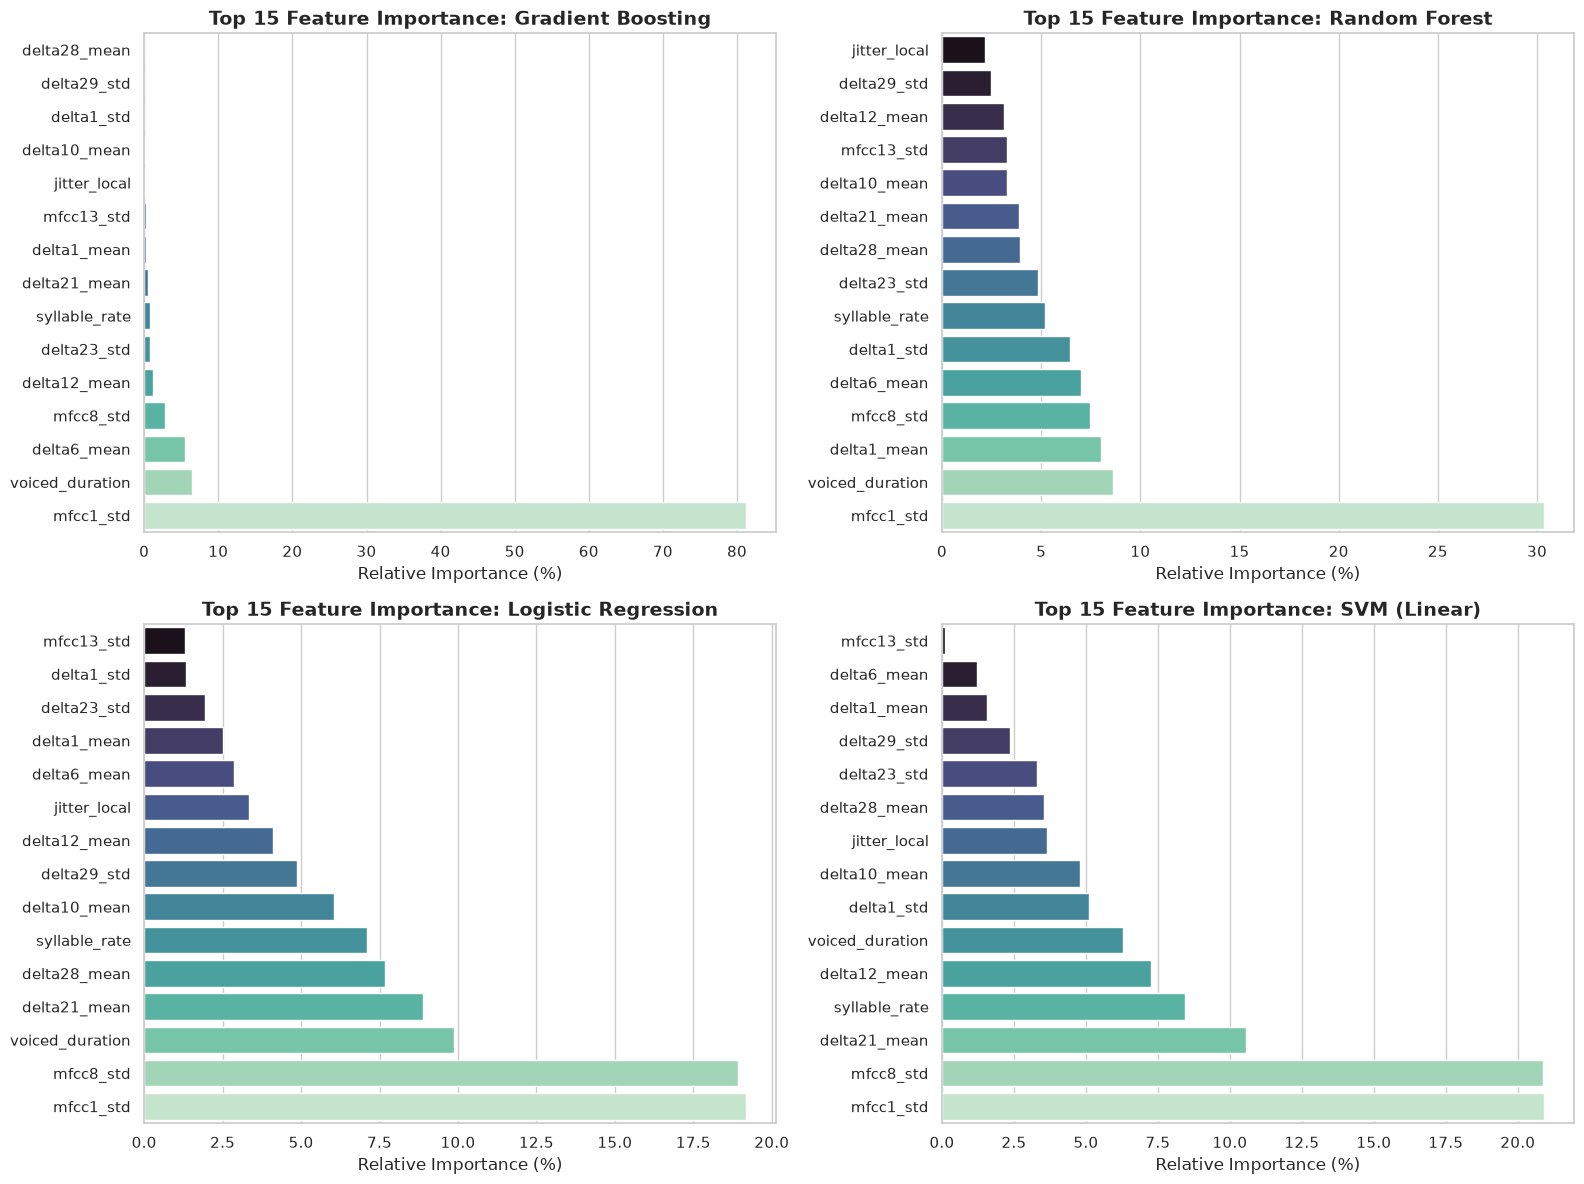

In [6]:
sns.set_theme(style="whitegrid")

# --- Load & filter fitur (ulang untuk memastikan) ---
df = pd.read_csv('features.csv')
drop_cols = ['speaker_id', 'class', 'gender', 'location',
             'notes', 'file_path', 'file_path_processed']
bias_cols = [
    c for c in df.columns
    if (c.startswith('mfcc') and c.endswith('_mean'))
    or c in ['f0_mean', 'f1_mean', 'f2_mean', 'f1f2_ratio']
]
feature_cols = [c for c in df.columns if c not in drop_cols and c not in bias_cols]

X = df[feature_cols].values
y = df['class'].values

# --- Scaling & feature selection ---
X_scaled   = StandardScaler().fit_transform(X)
selector   = SelectKBest(score_func=f_classif, k=15)
X_selected = selector.fit_transform(X_scaled, y)

selected_indices      = selector.get_support(indices=True)
selected_feature_names = np.array(feature_cols)[selected_indices]

# --- Model untuk ekstraksi importance ---
importance_models = {
    'Gradient Boosting':   GradientBoostingClassifier(
        n_estimators=100, random_state=42),
    'Random Forest':       RandomForestClassifier(
        n_estimators=300, max_depth=5,
        class_weight='balanced', random_state=42),
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=2000, random_state=42),
    'SVM (Linear)':        SVC(
        kernel='linear', class_weight='balanced', random_state=42)
}

# --- Plot grid 2x2 ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (name, model) in enumerate(importance_models.items()):
    model.fit(X_selected, y)

    # Ekstrak importance
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    else:
        importances = np.abs(model.coef_[0])

    # Normalisasi jadi persen
    importances = 100 * (importances / np.sum(importances))
    sorted_idx  = np.argsort(importances)

    ax = axes[idx]
    sns.barplot(x=importances[sorted_idx],
                y=selected_feature_names[sorted_idx],
                ax=ax, palette='mako', hue=selected_feature_names[sorted_idx],
                legend=False)
    ax.set_title(f'Top 15 Feature Importance: {name}',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Relative Importance (%)', fontsize=12)
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig('feature_importances_all_models.png', dpi=300, bbox_inches='tight')
plt.show()